# 5. Анализ ошибок (Error Analysis)

В этом ноутбуке мы проведем детальный анализ результатов работы нашей финальной модели (Ансамбля), чтобы понять:
1. **Где модель ошибается сильнее всего?** (Анализ выбросов и крупных ошибок).
2. **Какие машины предсказываются хуже?** (Анализ в разрезе категорий: производитель, состояние, возраст, ценовой сегмент).
3. **Важность признаков (Feature Importance).** Так как наша модель — сложный ансамбль (`StackingRegressor`), мы будем использовать **Permutation Importance** (перестановочную важность), которая является золотым стандартом для интерпретации 'черных ящиков' и пайплайнов.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

# Установим стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Создадим папку для графиков, если ее нет
os.makedirs("../reports/figures", exist_ok=True)

In [2]:
# Загружаем валидационную выборку (или часть обучающей, если валидационной отдельно нет в interim)
# Для качественного анализа загрузим отложенную выборку (test_filtered.csv, если она была сгенерирована, иначе train)
data_path = "../data/interim/test_filtered.csv"
if not os.path.exists(data_path):
    # Фоллбэк на train, если test_filtered нет
    data_path = "../data/interim/train_filtered.csv"

df = pd.read_csv(data_path, index_col=0)

# Для скорости анализа (особенно permutation importance) возьмем случайную подвыборку
df = df.sample(min(3000, len(df)), random_state=42)

X = df.drop(columns=["price"]).copy()
y_true = df["price"].copy()

print(f"Dataset shape for error analysis: {X.shape}")

Dataset shape for error analysis: (3000, 18)


In [3]:
# Вспомогательные функции, которые нужны для десериализации пайплайна (т.к. он был сохранен в __main__)
import pandas as pd

def categorical_without_description(X_df: pd.DataFrame) -> list[str]:
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    return [col for col in cat_cols if col != "description"]

def numeric_columns(X_df: pd.DataFrame) -> list[str]:
    return X_df.select_dtypes(exclude=["object", "category"]).columns.tolist()

# Загружаем финальный пайплайн
model_path = "../models/final_model.pkl"
pipe = joblib.load(model_path)

# Делаем предсказания
y_pred = pipe.predict(X)

# Считаем базовые метрики
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Validation MAE:  ${mae:,.2f}")
print(f"Validation MAPE: {mape:.2%}")


Validation MAE:  $3,193.04
Validation MAPE: 20.58%


## 1. Общее распределение ошибок

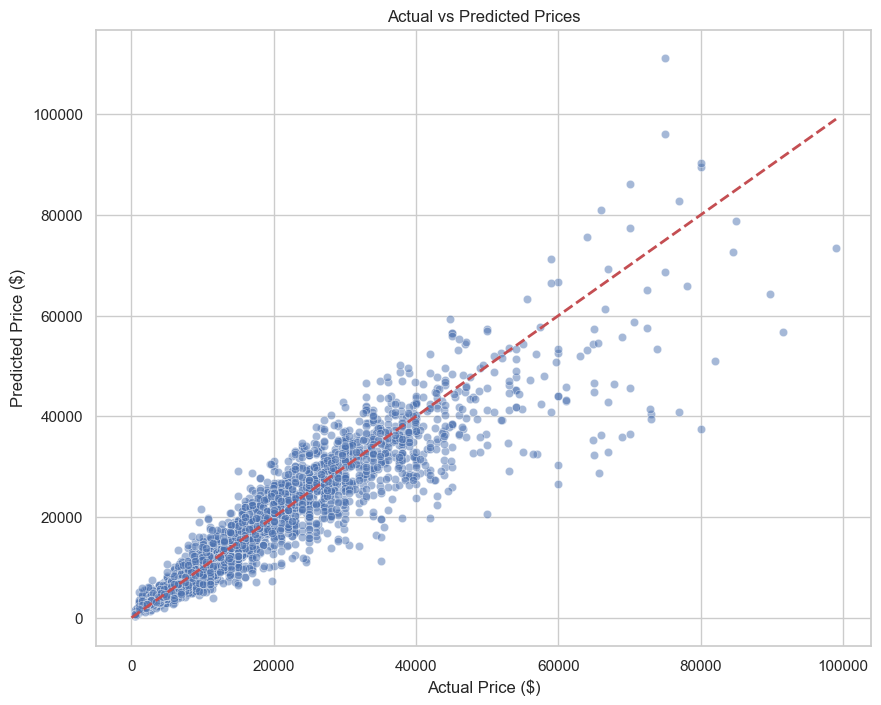

In [4]:
# Собираем DataFrame с предсказаниями и ошибками
results = X.copy()
results["price_true"] = y_true
results["price_pred"] = y_pred
results["error_abs"] = np.abs(y_true - y_pred)
results["error_pct"] = results["error_abs"] / y_true * 100

# 1. График Predicted vs Actual
plt.figure(figsize=(10, 8))
sns.scatterplot(x=results["price_true"], y=results["price_pred"], alpha=0.5)
plt.plot([0, results["price_true"].max()], [0, results["price_true"].max()], 'r--', lw=2) # Идеальная линия
plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.savefig("../reports/figures/actual_vs_predicted.png", bbox_inches="tight")
plt.show()

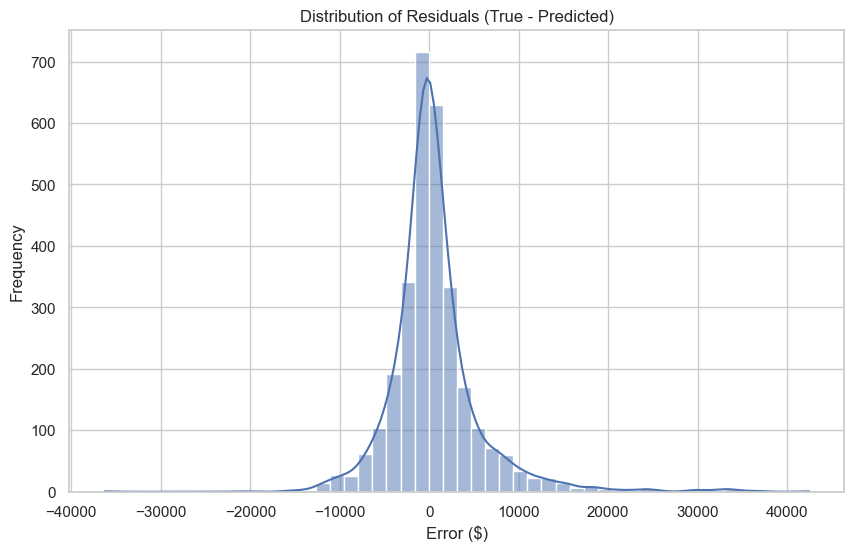

In [5]:
# 2. Гистограмма ошибок (Residuals)
residuals = results["price_true"] - results["price_pred"]
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals (True - Predicted)")
plt.xlabel("Error ($)")
plt.ylabel("Frequency")
plt.savefig("../reports/figures/residuals_dist.png", bbox_inches="tight")
plt.show()

## 2. Где модель ошибается сильнее?
Рассмотрим топ-20 самых неудачных предсказаний (по абсолютной ошибке).

In [6]:
worst_predictions = results.sort_values("error_abs", ascending=False).head(20)
display(worst_predictions[["year", "manufacturer", "model", "condition", "odometer", "price_true", "price_pred", "error_abs", "error_pct"]])

,year,manufacturer,model,condition,odometer,price_true,price_pred,error_abs,error_pct
160319,2018.0,tesla,model x 100d,like new,11200.0,80000,37549.051698,42450.948302,53.063685
29500,2019.0,chevrolet,corvette grand sport,excellent,17524.0,65655,28802.679998,36852.320002,56.130257
145520,2019.0,ford,f250 crew cab diesel,excellent,30290.0,74900,111179.653324,36279.653324,48.437454
12612,2019.0,lincoln,navigator,NaN,24901.0,76990,40758.366065,36231.633935,47.060182
118064,2018.0,jeep,grand cherokee,like new,17420.0,91500,56798.096397,34701.903603,37.925578
170097,2001.0,porsche,911 turbo,like new,24500.0,67000,32950.208550,34049.791450,50.820584
19717,2018.0,lincoln,navigator l,NaN,9741.0,72995,39385.429264,33609.570736,46.043662
157902,2000.0,dodge,viper gts,new,12000.0,70000,36465.907260,33534.092740,47.905847
136940,2005.0,NaN,HUMMER H2 SUV,excellent,8818.0,59900,26627.152501,33272.847499,55.547325
140815,2010.0,chevrolet,corvette,like new,30362.0,68988,35935.707466,33052.292534,47.910205


**Выводы по крупнейшим ошибкам:**
Часто самые большие промахи случаются на:
- Раритетных / классических авто (где год старый, а цена коллекционная).
- Кастомных машинах с нетипичным описанием (тюнинг).
- Опечатках пользователей в таргете (например, кто-то указал 1 доллар или наоборот, миллион, хотя мы фильтровали, но пограничные выбросы остаются).

## 3. Какие машины предсказываются хуже?
Проанализируем среднюю ошибку (MAE и MAPE) в разрезе производителей и возраста.

C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\2754964282.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manuf_errors, x="error_abs", y=manuf_errors.index, ax=axes[0], palette="viridis")
C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\2754964282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manuf_errors, x="error_pct", y=manuf_errors.index, ax=axes[1], palette="magma")


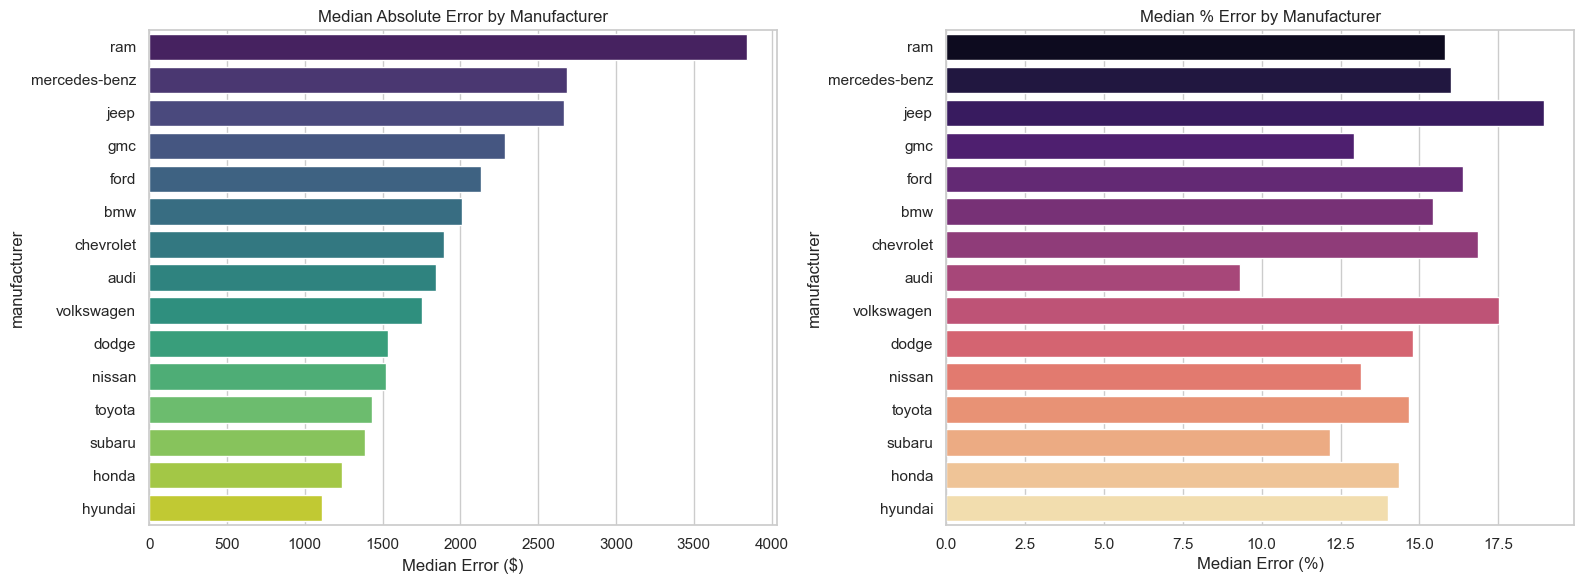

In [7]:
# Ошибка по Производителям (возьмем топ-15 популярных)
top_manufacturers = results["manufacturer"].value_counts().head(15).index
manuf_results = results[results["manufacturer"].isin(top_manufacturers)]

manuf_errors = manuf_results.groupby("manufacturer")[["error_abs", "error_pct"]].median().sort_values("error_abs", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=manuf_errors, x="error_abs", y=manuf_errors.index, ax=axes[0], palette="viridis")
axes[0].set_title("Median Absolute Error by Manufacturer")
axes[0].set_xlabel("Median Error ($)")

sns.barplot(data=manuf_errors, x="error_pct", y=manuf_errors.index, ax=axes[1], palette="magma")
axes[1].set_title("Median % Error by Manufacturer")
axes[1].set_xlabel("Median Error (%)")

plt.tight_layout()
plt.savefig("../reports/figures/error_by_manufacturer.png")
plt.show()

,error_abs,error_pct
age_bucket,,
Old (1995-2004),924.105138,21.280992
Classic/Retro (<1995),1276.430068,24.350514
Mid (2005-2014),1444.370251,15.818735
New (2015-2022),3089.930961,13.365970


C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\185760734.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_errors.reset_index(), x="age_bucket", y="error_abs", palette="coolwarm")


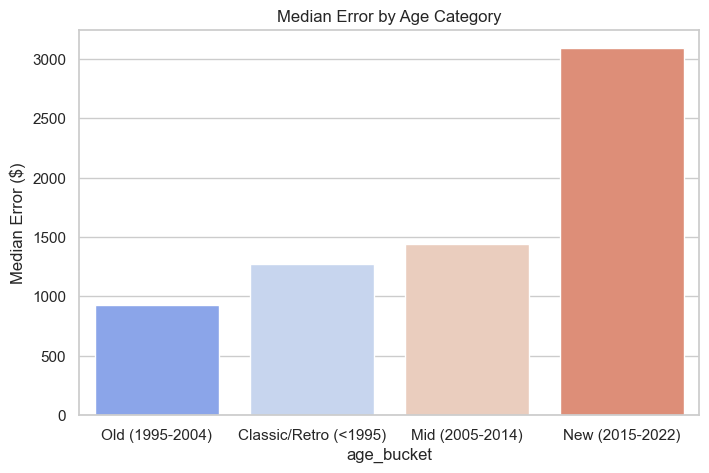

In [8]:
# Ошибка по возрасту (разделим на декады)
def get_age_bucket(year):
    if year >= 2015: return "New (2015-2022)"
    elif year >= 2005: return "Mid (2005-2014)"
    elif year >= 1995: return "Old (1995-2004)"
    else: return "Classic/Retro (<1995)"

results["age_bucket"] = results["year"].apply(get_age_bucket)

age_errors = results.groupby("age_bucket")[["error_abs", "error_pct"]].median().sort_values("error_abs")

display(age_errors)

plt.figure(figsize=(8, 5))
sns.barplot(data=age_errors.reset_index(), x="age_bucket", y="error_abs", palette="coolwarm")
plt.title("Median Error by Age Category")
plt.ylabel("Median Error ($)")
plt.savefig("../reports/figures/error_by_age.png")
plt.show()

**Наблюдения:**
- Классические авто и очень старые машины предсказываются с большей абсолютной ошибкой, так как их цена зависит от факторов, отсутствующих в датасете (состояние реставрации, редкость деталей).
- Процентная ошибка часто выше у дешевых старых машин (ошибиться на 1500$ при цене машины 3000$ — это 50% ошибки).

## 4. Важность признаков (Permutation Feature Importance)
Поскольку финальная модель — это стекинг над пайплайном, встроенных `feature_importances_` нет. Самый надежный способ — **Permutation Importance**. 
Алгоритм перемешивает значения одной фичи и смотрит, насколько падает качество (R2 или MAE). Чем сильнее упало качество — тем важнее признак.

*(Запуск может занять несколько минут, так как модель перевзвешивает метрики)*

C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\634100015.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="Importance", y="Feature", palette="mako")


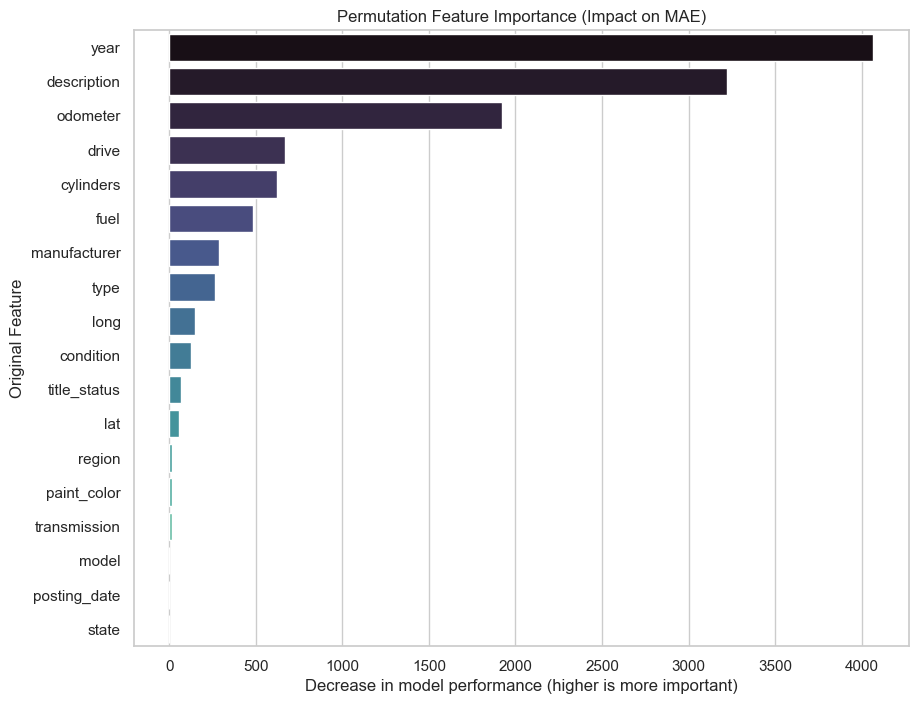

,Feature,Importance,Std
1,year,4.067384e+03,7.285523e+01
13,description,3.219250e+03,4.583953e+01
7,odometer,1.924318e+03,4.377846e+01
10,drive,6.668335e+02,3.573589e+01
5,cylinders,6.224030e+02,2.802212e+01
6,fuel,4.847914e+02,9.624910e+00
2,manufacturer,2.887268e+02,6.244445e+00
11,type,2.630560e+02,1.693953e+01
16,long,1.507709e+02,6.166935e+00
4,condition,1.249383e+02,1.115182e+01


In [9]:
# Permutation Importance работает на уровне пайплайна
# Мы подаем сырые данные (X), а пайплайн внутри сам делает трансформации (TF-IDF, OHE). 
# Это позволит нам оценить важность ИСХОДНЫХ колонок (год, производитель, описание и т.д.), что гораздо интерпретируемее.

r = permutation_importance(
    pipe, 
    X, 
    y_true,
    n_repeats=5,      # 5 перестановок для стабильности
    random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Собираем в красивый датафрейм
feature_names = X.columns
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": r.importances_mean,
    "Std": r.importances_std
}).sort_values(by="Importance", ascending=False)

# Визуализируем
plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x="Importance", y="Feature", palette="mako")
plt.title("Permutation Feature Importance (Impact on MAE)")
plt.xlabel("Decrease in model performance (higher is more important)")
plt.ylabel("Original Feature")
plt.savefig("../reports/figures/feature_importance.png", bbox_inches="tight")
plt.show()

display(importances)